Assigment 3: Greedy Algorithms
In this assignment, we will explore greedy algorithms for makespan scheduling. We will see how a greedy algorithm can sometimes provide a solution that is guaranteed to be within some constant factor of the best possible solution. Please fill out the missing answers and the missing code below. Note that the coding part of this assignment should be simple given where we are in this class but the ungraded answers will hopefully be most instructive for this assignment.

See https://jeffe.cs.illinois.edu/teaching/algorithms/notes/J-approx.pdf section J1 for more details.

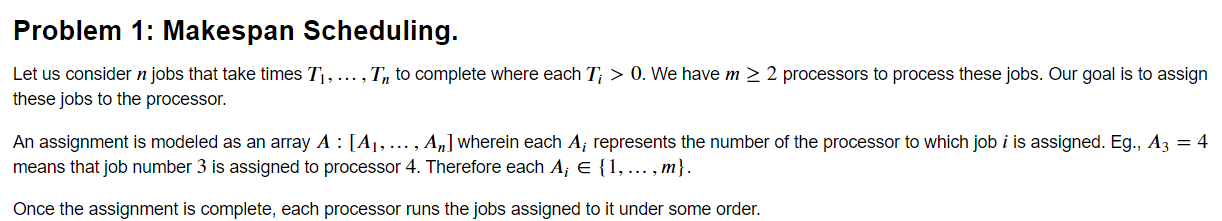
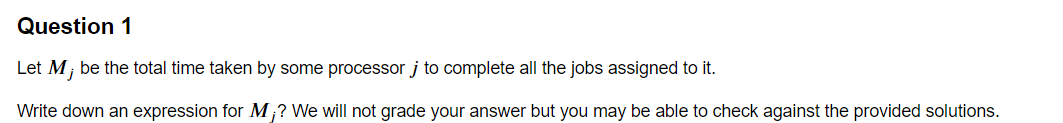
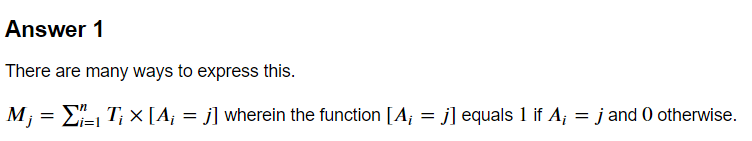
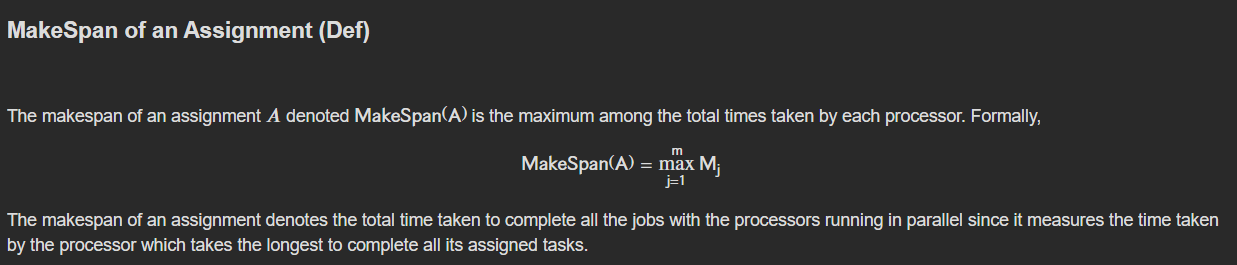
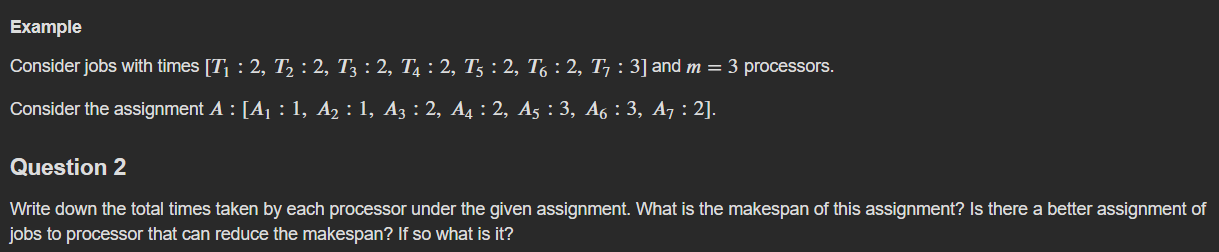
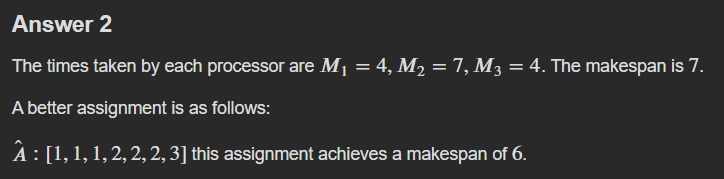

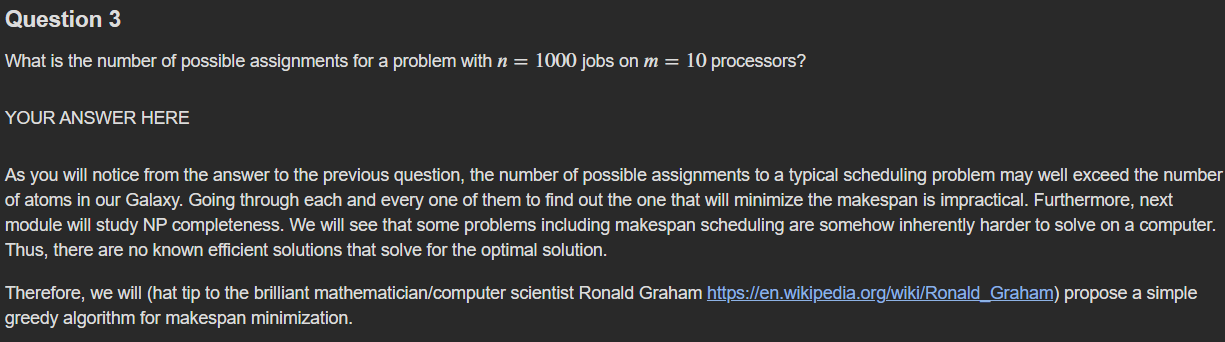 

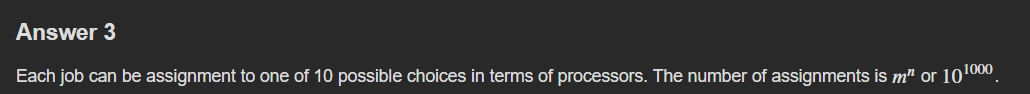
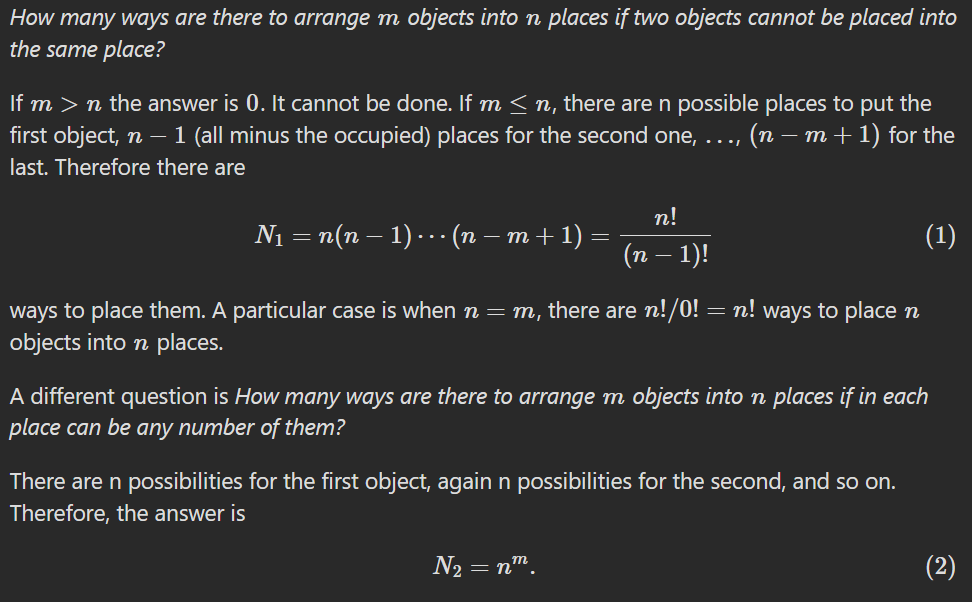

In [19]:
# Problem A: Calculate Makespan of an Assignment

def compute_makespan(times, m, assign):
    # times is an array of job times of size n
    # m is the number of processors
    # assign is an array of size n whose entries are between 0 to m-1 
    # indicating the processor number for
    # the corresponding job.
    # Return: makespan of the assignment
    # your code here - brute force - each job can be placed to either of m processors
    processor_time_total = [0]*m
    n = len(times)
    for job in range(n):
        processor_time_total[assign[job]] +=  times[job]
    return max(processor_time_total)



In [20]:
## BEGIN TESTS
print('Test 1 ... ', end = '')
times = [2, 2, 2, 2, 3, 3, 2]
assigns = [0, 0, 0, 0, 1, 1, 2]
m = 3
s = compute_makespan(times, m, assigns)
assert s == 8, f'Expected makespan is 8, your code returned: {s}'
print(' passed!')

print('Test 2 ...', end='')
times = [2, 1, 2, 2, 1, 3, 2, 1, 1, 3]
assigns = [0, 1, 0, 1, 0, 1, 0, 1, 0, 1]
m = 3
s = compute_makespan(times, m, assigns)
assert s == 10, f' Expected makespan is 10, your code returned {s}'
print('  passed!')
print('Tests passed: 10 points!')

## END TESTS

Test 1 ...  passed!
Test 2 ...  passed!
Tests passed: 10 points!


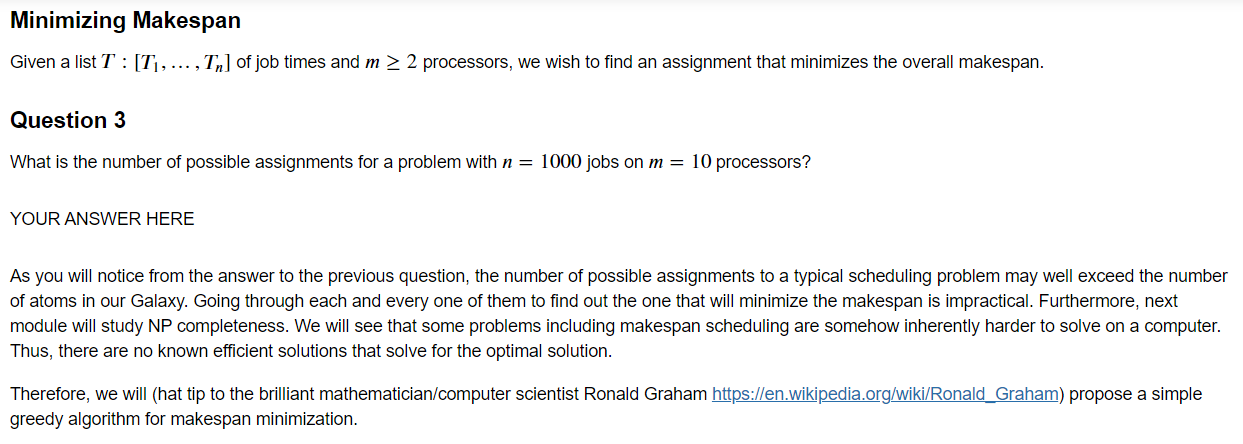
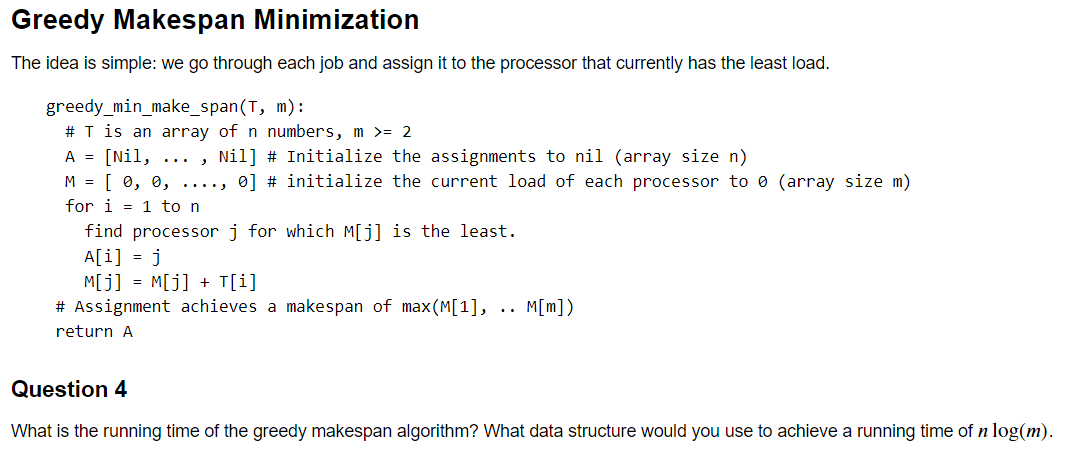
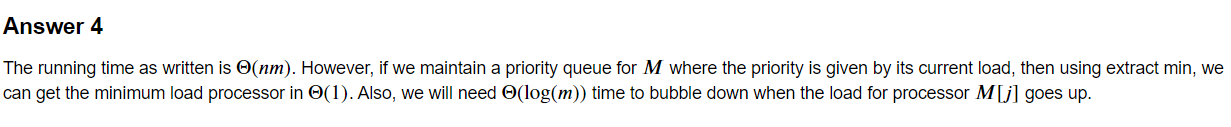

In [21]:
# Problem B: Implement the Greedy Makespan Algorithm
import heapq

def greedy_makespan_min(times, m):
    # times is a list of n jobs.
    assert len(times) >= 1
    assert all(elt >= 0 for elt in times)
    assert m >= 2
    n = len(times)
    # please do not reorder the jobs in times or else tests will fail.
    # you can implement a priority queue if you would like.
    # use https://docs.python.org/3/library/heapq.html heapq data structure 
    # Return a tuple of two things: 
    #    - Assignment list of n numbers from 0 to m-1
    #    - The makespan of your assignment
    # your code here
    n = len(times)
    assignments = {} # store array of jobs assigned to each processor
    pq = [] # priority queue to hold which processor has minimum load
    for processor in range(m): #initialization 
        assignments[processor] = [] # assign empty job list to processors
        heapq.heappush(pq, (0, processor)) # all processors have load 0 initially
    job_processor = []
    for job in range(n): # assign n jobs using greedy algorithm
        (least_load, least_loaded_processor) = heapq.heappop(pq) # pq fopefully breaks ties arbitrarily
        assignments[least_loaded_processor].append(job)
        heapq.heappush(pq,(least_load+times[job], least_loaded_processor))
        job_processor.append(least_loaded_processor)
    (largest_load, largest_load_processor) = heapq.nlargest(n,pq)[0]
    return (job_processor, largest_load)



In [22]:
## BEGIN TESTS
def do_test(times, m, expected):
    (a, makespan) = greedy_makespan_min(times,m )
    print('\t Assignment returned: ', a)
    print('\t Claimed makespan: ', makespan)
    assert compute_makespan(times, m, a) == makespan, 'Assignment returned is not consistent with the reported makespan'
    assert makespan == expected, f'Expected makespan should be {expected}, your core returned {makespan}'
    print('Passed')
print('Test 1:')
times = [2, 2, 2, 2, 2, 2, 2, 2, 3] 
m = 3
expected = 7
do_test(times, m, expected)


print('Test 2:')
times = [1]*20 + [5]
m = 5
expected =9
do_test(times, m, expected)

print('Test 3:')
times = [1]*40 + [2]
m = 20
expected = 4
do_test(times, m, expected)
print('All tests passed: 15 points!')
## END TESTS

Test 1:
	 Assignment returned:  [0, 1, 2, 0, 1, 2, 0, 1, 2]
	 Claimed makespan:  7
Passed
Test 2:
	 Assignment returned:  [0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0]
	 Claimed makespan:  9
Passed
Test 3:
	 Assignment returned:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 0]
	 Claimed makespan:  4
Passed
All tests passed: 15 points!


: 

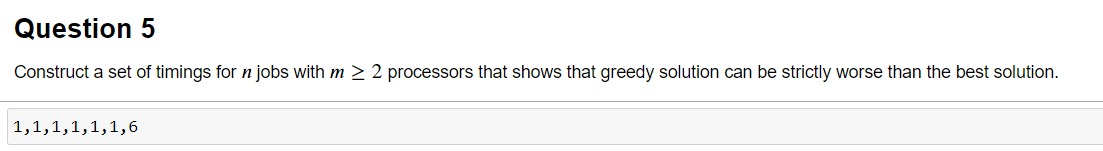
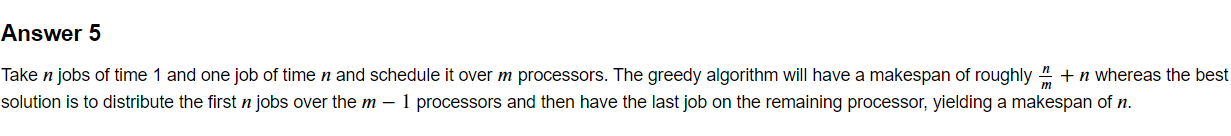

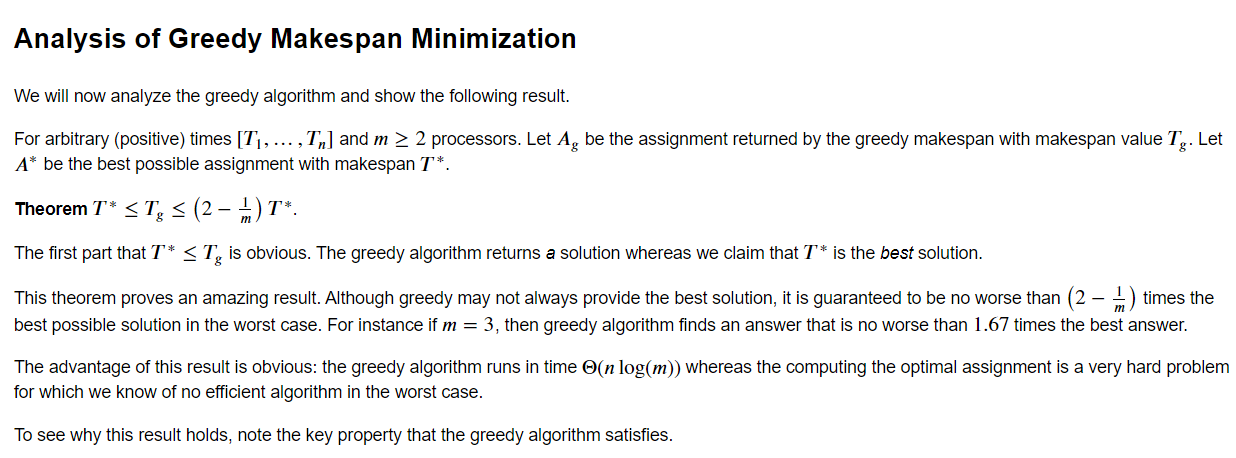

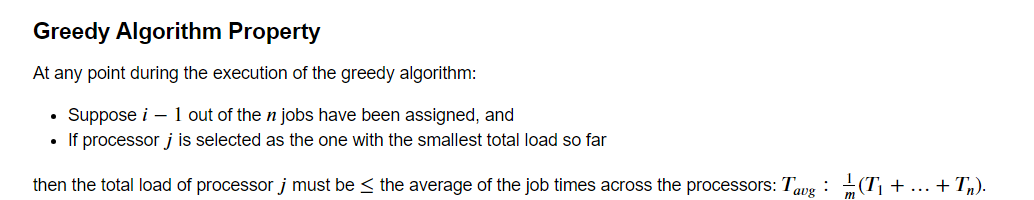
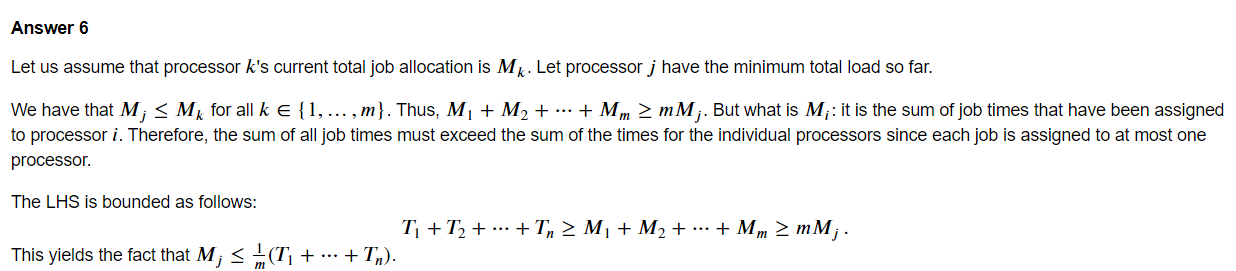
Self Note - Looks the job times are ordered in ascending since last job is supposed to be taking most time in the argument below ? (though that could be assumed only for offline strategy where all job times already known)
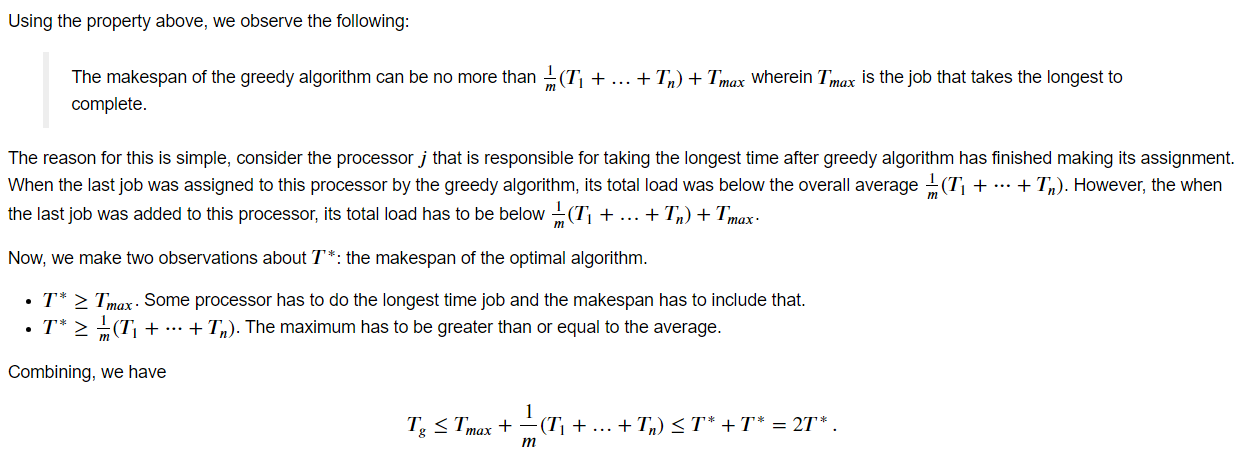
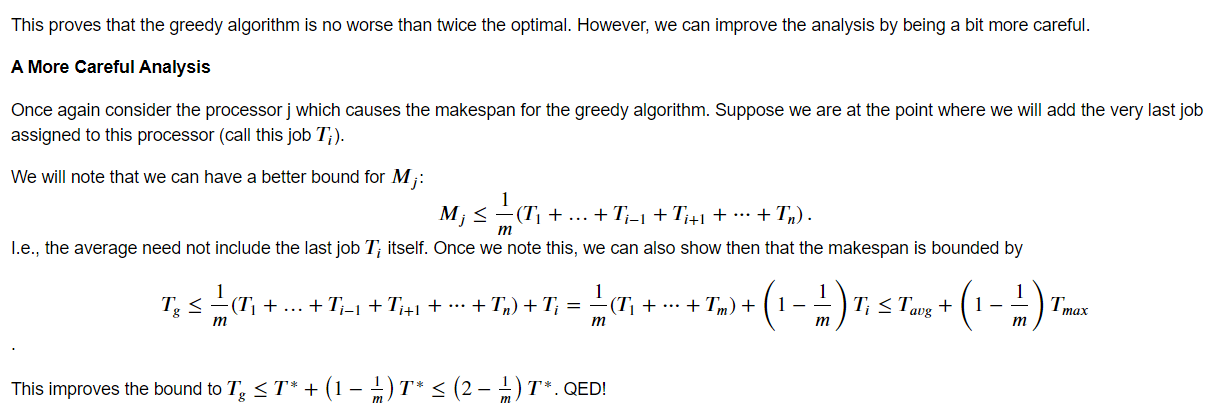

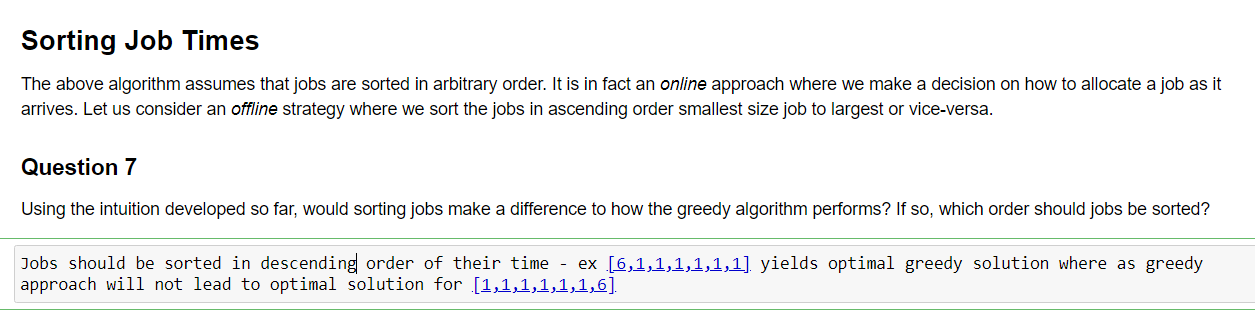
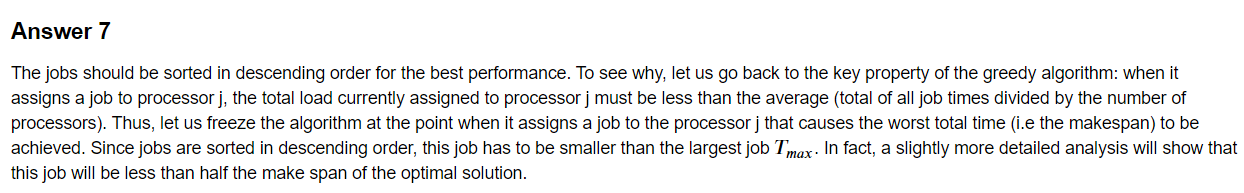
